# Dataset 1 - realTraffic/occupancy_6005

## 0. What we’re doing and why

We’re preparing a rigorous, data‐driven justification for applying EVT-based detectors (SPOT/DSPOT) to a real‐world traffic dataset. We need to understand the data’s characteristics, validate EVT’s assumptions, and foresee how well DSPOT will perform—then position it against other streaming detectors.

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt

from scipy.stats import genpareto, kstest
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL

# Load realTraffic dataset
df = pd.read_csv("../../data/raw_data/occupancy_6005.csv", parse_dates=[0])
df.columns = ["timestamp", "value"]

## 1. Simple EDA

In [2]:
# Inspect the structure
print(df.head())
print(df.describe())

            timestamp  value
0 2015-09-01 13:45:00   3.06
1 2015-09-01 13:50:00   6.44
2 2015-09-01 13:55:00   5.17
3 2015-09-01 14:00:00   3.83
4 2015-09-01 14:05:00   4.50
                           timestamp        value
count                           2380  2380.000000
mean   2015-09-11 03:34:01.285714432     4.495147
min              2015-09-01 13:45:00     0.000000
25%              2015-09-08 12:26:15     1.940000
50%              2015-09-12 09:31:00     3.830000
75%              2015-09-15 08:37:15     6.170000
max              2015-09-17 16:24:00    22.280000
std                              NaN     3.404555


#### Main observations:
- Regular sampling every 5 minutes
- Range from 0 to 22 

#### Implication for EVT-AD: 
good candidate for EVT since we have enough magnitude range.

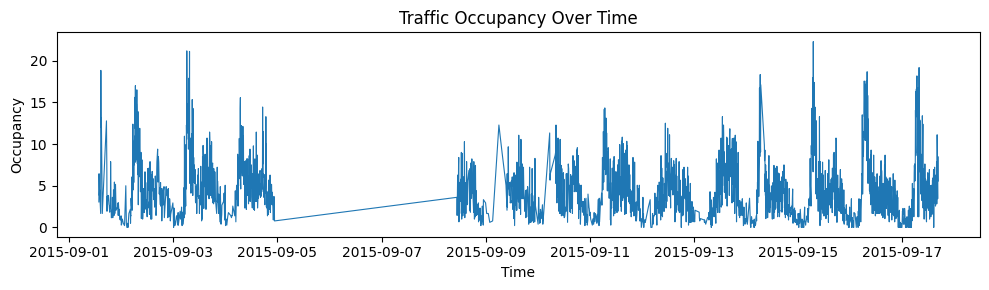

In [3]:
# Plot the raw series
plt.figure(figsize=(10,3))
plt.plot(df["timestamp"], df["value"], linewidth=0.8)
plt.title("Traffic Occupancy Over Time")
plt.xlabel("Time")
plt.ylabel("Occupancy")
plt.tight_layout()
plt.show()

In [2]:
import json
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Load windows
with open("../../data/raw_data/combined_windows.json") as f:
    all_windows = json.load(f)

dataset_key = "realTraffic/occupancy_6005.csv"
window_strs = all_windows.get(dataset_key, [])

raw_windows = [
    (datetime.strptime(start, "%Y-%m-%d %H:%M:%S.%f"),
     datetime.strptime(end,   "%Y-%m-%d %H:%M:%S.%f"))
    for start, end in window_strs
]

def align_windows_to_series(windows, ts_series: pd.Series):
    """
    Convert a list of (start,end) datetimes to pandas Timestamps that match the
    timezone-awareness of ts_series.index (DatetimeIndex).
    """
    idx = pd.to_datetime(ts_series)
    tz = getattr(idx.dt, "tz", None)

    aligned = []
    for s, e in windows:
        s_ts = pd.Timestamp(s)
        e_ts = pd.Timestamp(e)
        # Ensure start <= end
        if e_ts < s_ts:
            s_ts, e_ts = e_ts, s_ts
        # Localize/convert like the data
        if tz is None:
            # make both naive
            s_ts = s_ts.tz_localize(None) if s_ts.tzinfo else s_ts
            e_ts = e_ts.tz_localize(None) if e_ts.tzinfo else e_ts
        else:
            # make both aware and convert to tz
            s_ts = (s_ts.tz_localize("UTC") if s_ts.tzinfo is None else s_ts).tz_convert(tz)
            e_ts = (e_ts.tz_localize("UTC") if e_ts.tzinfo is None else e_ts).tz_convert(tz)
        aligned.append((s_ts, e_ts))
    return aligned

def merge_overlapping(intervals):
    """Merge overlapping/adjacent intervals [(s,e), ...] sorted by start."""
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    for s, e in intervals[1:]:
        last_s, last_e = merged[-1]
        if s <= last_e:
            merged[-1] = (last_s, max(last_e, e))
        else:
            merged.append((s, e))
    return merged

anomaly_windows = align_windows_to_series(raw_windows, df["timestamp"])
anomaly_windows = merge_overlapping(anomaly_windows)

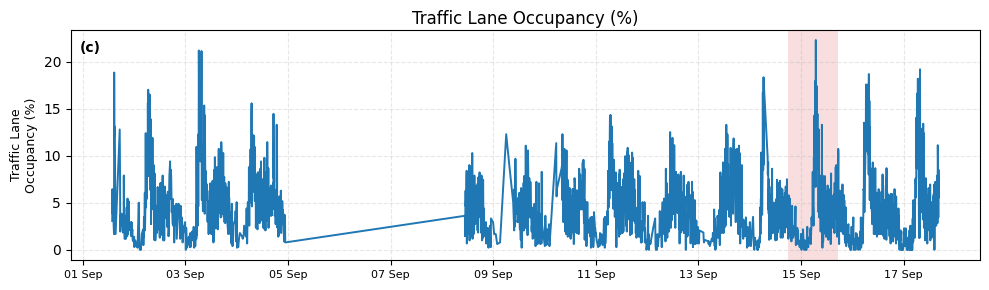

In [22]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
import matplotlib.dates as mdates

# Plot raw series
anomaly_windows = [(pd.to_datetime(s), pd.to_datetime(e)) for s, e in window_strs]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df["timestamp"], df["value"], linewidth=1.4,  color="tab:blue")
ax.set_title("Traffic Lane Occupancy (%)", loc="center", pad=4)
ax.set_ylabel("Traffic Lane\nOccupancy (%)", fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.tick_params(axis="x", which="major", labelsize=8)
ax.grid(alpha=0.3, linestyle="--")

# Shade anomaly windows
for s, e in anomaly_windows:
    ax.axvspan(s, e, facecolor="tab:red", alpha=0.15, lw=0, zorder=0)

# Add legend handle for the shaded regions
legend_patch = Patch(facecolor="tab:red", alpha=0.15, label="Anomaly window")

ax.text(0.01, 0.95, "(c)", transform=ax.transAxes, va="top", ha="left",
        fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("../../output/occupancy/occupancy_raw_seris.png", dpi=300, bbox_inches="tight")
plt.show()


#### Main observations:
- September 1–5 data, then gap until September 9 - data collection paused? or any other issue for missing data.
- September 9-11 also has a few missing data points.
- Clear daily peaks and off-peak troughs.
- A few distinct high spikes interspersed with quieter periods.

#### Implication for EVT-AD: 
strong seasonality (daily periodicity) + isolated extreme events.

Since this research does not focus on the misingness of the data, we will segement the dataset and will continue working with the second part starting Sep 9.

In [4]:
# Define the post-gap start time
post_gap_start = pd.Timestamp("2015-09-09 00:00:00")
# Filter
df_post = df[df["timestamp"] >= post_gap_start].reset_index(drop=True)
clean_data = df_post[["timestamp", "value"]].copy()
clean_data.to_csv("../../data/clean_data/post_gap_occupancy.csv", index=False)

#### Now let's explore the type of drift in the dataset.

In order to detect the presence of the drift, we can use rolling statistics.

Rolling statistics let us see how the baseline (mean) and volatility (std) change over time, which is exactly what “concept drift” means.

#### What rolling window to choose?

The dataset is recorded every 5 minutes. One day has 24h × 60min / 5min = 288 samples. So let's choose 144 (half of 288) as a compromise window to show both intra-day trends (≈12 hours) and to get a smoother estimate without waiting a full day.

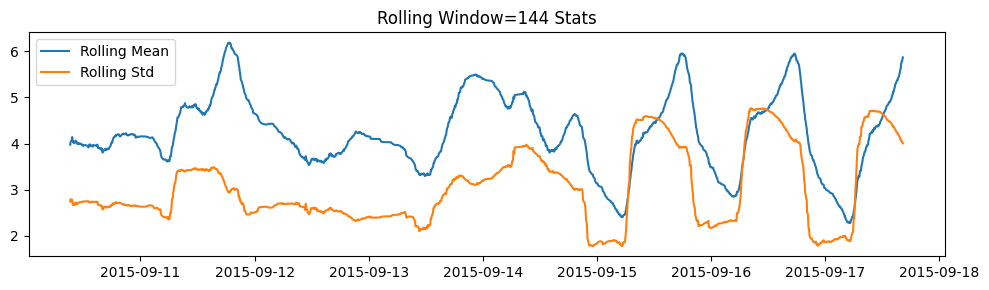

In [5]:
# Rolling statistics to visualise drift
window = 144
clean_data["roll_mean"] = clean_data["value"].rolling(window).mean()
clean_data["roll_std"]  = clean_data["value"].rolling(window).std()

# Plot the results
plt.figure(figsize=(10,3))
plt.plot(clean_data["timestamp"], clean_data["roll_mean"], label="Rolling Mean")
plt.plot(clean_data["timestamp"], clean_data["roll_std"],  label="Rolling Std")
plt.legend()
plt.title(f"Rolling Window={window} Stats")
plt.tight_layout()
plt.show()

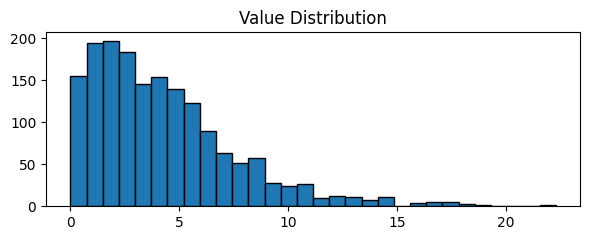

In [6]:
# Check the value distribution
plt.figure(figsize=(6,2.5))
plt.hist(clean_data["value"], bins=30, edgecolor="k")
plt.title("Value Distribution")
plt.tight_layout()
plt.show()

#### Main observations:
1. Rolling mean swings between 3 and 6 over the series.
2. Rolling STD hovers 2 and 5, with peaks corresponding to high-variance periods.
3. The Value Distribution shows quite heavy right tail
   
#### Implication:
both mean and variance drift over time (not purely stationary).

Now, let'c check the ACF 

<Figure size 800x300 with 0 Axes>

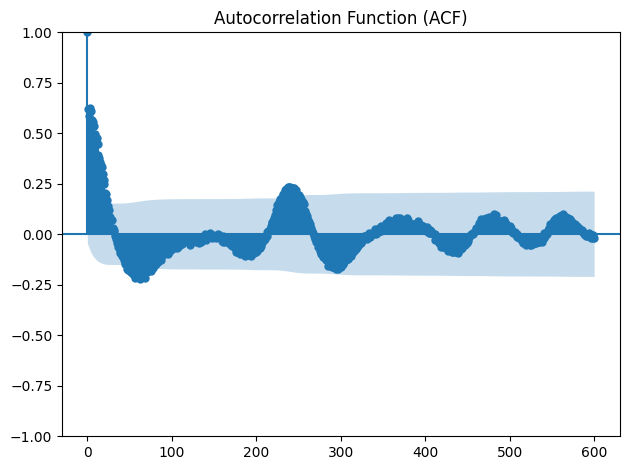

In [7]:
value = clean_data["value"].values

plt.figure(figsize=(8, 3))
plot_acf(value, lags=600)
plt.title("Autocorrelation Function (ACF)")
plt.tight_layout()
plt.show()


????? Peaks and troughs recur approximately every ~144 lags, which corresponds to one day of data if you're using 5-minute intervals (144 × 5min = 720min = 12 hours, so cycle = half-day or day)

### 2. Change Point Detection 

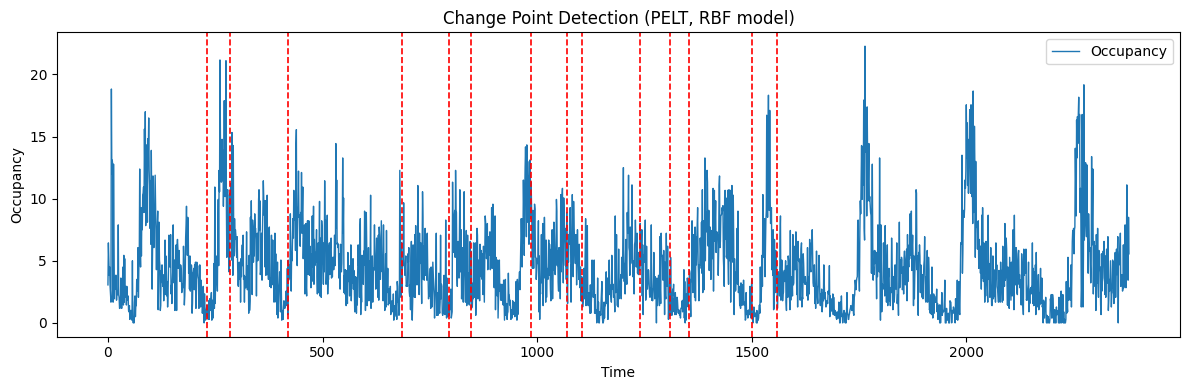

In [118]:
# Change point detection
model = rpt.Pelt(model="rbf").fit(values)
change_indices = model.predict(pen=10)

# Plot full signal with change points
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["value"], label="Occupancy", linewidth=1)

for cp in change_indices[:-1]:  # Exclude final index (end of signal)
    plt.axvline(df.index[cp], color='red', linestyle='--', lw=1.2)

plt.title("Change Point Detection (PELT, RBF model)")
plt.xlabel("Time")
plt.ylabel("Occupancy")
plt.legend()
plt.tight_layout()
plt.show()
